In [1]:
import pandas as pd


df = pd.read_csv('Credit.csv')

In [2]:
df['Income_ind'] = df['Income'] > 50 
df['Income_ind'].astype('bool')
df.pop('Income') 
df = df.dropna()
print(df.head())

   Unnamed: 0  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0           1   3606     283      2   34         11    Male      No     Yes   
1           2   6645     483      3   82         15  Female     Yes     Yes   
2           3   7075     514      4   71         11    Male      No      No   
3           4   9504     681      3   36         11  Female      No      No   
4           5   4897     357      2   68         16    Male      No     Yes   

   Ethnicity  Balance  Income_ind  
0  Caucasian      333       False  
1      Asian      903        True  
2      Asian      580        True  
3      Asian      964        True  
4  Caucasian      331        True  


In [3]:

cat_cols = ["Gender", "Student", "Married", "Ethnicity"]
for c in cat_cols:
    df[c] = df[c].astype("category")

df = pd.get_dummies(df, drop_first=True)
print(df)

     Unnamed: 0  Limit  Rating  Cards  Age  Education  Balance  Income_ind  \
0             1   3606     283      2   34         11      333       False   
1             2   6645     483      3   82         15      903        True   
2             3   7075     514      4   71         11      580        True   
3             4   9504     681      3   36         11      964        True   
4             5   4897     357      2   68         16      331        True   
..          ...    ...     ...    ...  ...        ...      ...         ...   
395         396   4100     307      3   32         13      560       False   
396         397   3838     296      5   65         17      480       False   
397         398   4171     321      5   67         12      138        True   
398         399   2525     192      1   44         13        0       False   
399         400   5524     415      5   64          7      966       False   

     Gender_Female  Student_Yes  Married_Yes  Ethnicity_Asian  

In [8]:
train_idx = int(0.8 * len(df))
train = df[:train_idx]
test = df[train_idx:]

x_train_cards = train.drop(columns=["Cards"])
y_train_cards = train["Cards"]

x_train_income = train.drop(columns=["Income_ind"])
y_train_income = train["Income_ind"]

x_test_cards = test.drop(columns=["Cards"])
y_test_cards = test["Cards"]

x_test_income = test.drop(columns=["Income_ind"])
y_test_income = test["Income_ind"]


[0.90625 0.90625 0.8125  0.9375  0.84375 0.90625 0.96875 0.96875 0.90625
 0.9375 ]


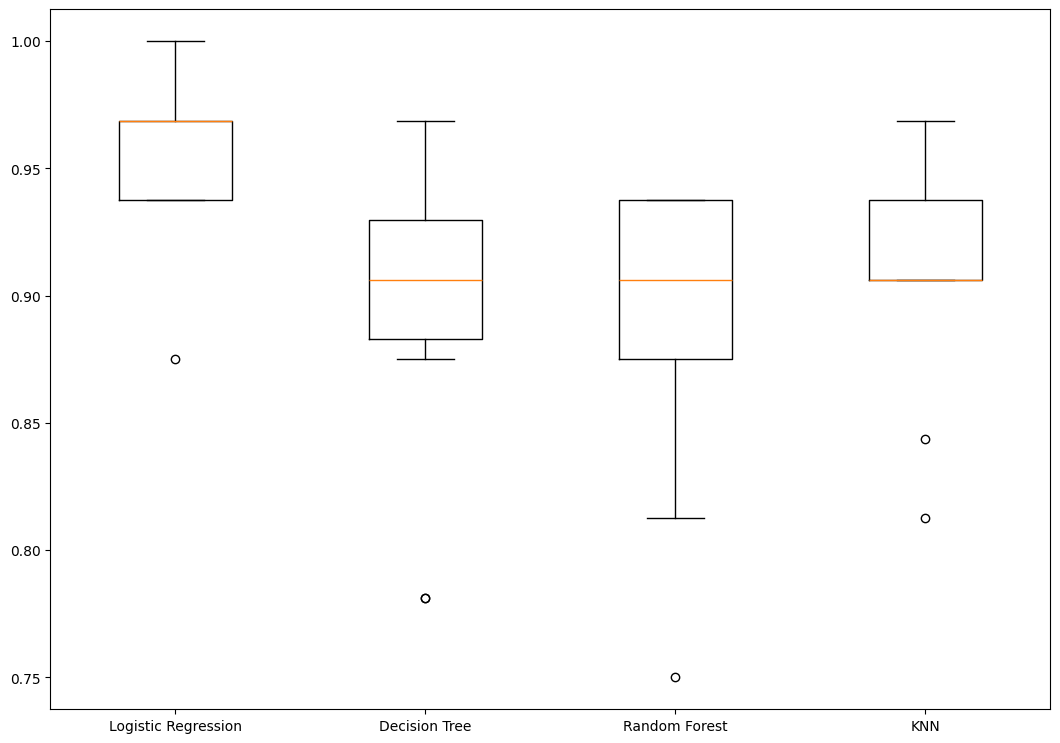

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn import ensemble
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=6)

scores_income = [
    cross_val_score(LogisticRegression(max_iter=1000, solver='newton-cg'), x_train_income, y_train_income, cv=kf, scoring='accuracy'),
    cross_val_score(tree.DecisionTreeClassifier(), x_train_income, y_train_income, cv=kf),
    cross_val_score(ensemble.RandomForestClassifier(n_estimators=100, max_depth=10), x_train_income, y_train_income, cv=kf),
    cross_val_score(KNeighborsClassifier(n_neighbors=7), x_train_income, y_train_income, cv=kf)
]


fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
bp = ax.boxplot(scores_income, tick_labels=['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'])
plt.show()


[array([0.375, 0.35 , 0.375, 0.6  , 0.3  , 0.3  , 0.3  , 0.375, 0.1  ,
       0.425]), array([0.325, 0.225, 0.175, 0.225, 0.225, 0.125, 0.275, 0.175, 0.1  ,
       0.175]), array([0.225, 0.35 , 0.225, 0.425, 0.225, 0.2  , 0.25 , 0.325, 0.175,
       0.375]), array([0.15 , 0.325, 0.2  , 0.3  , 0.125, 0.175, 0.275, 0.325, 0.2  ,
       0.3  ])]


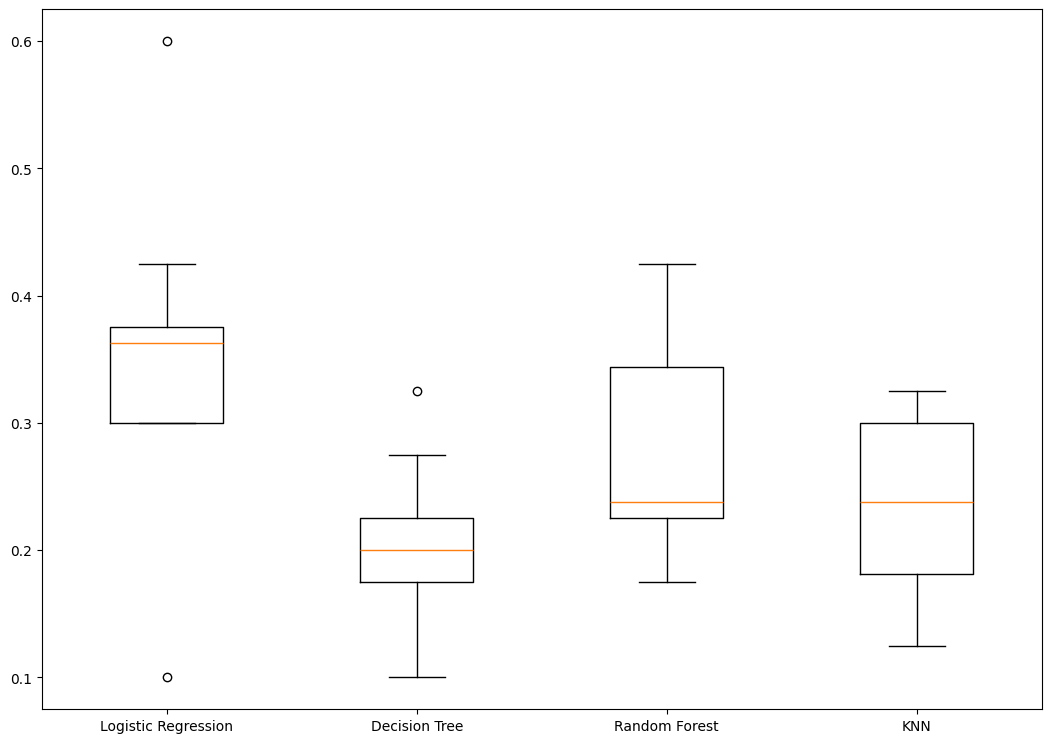

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn import ensemble
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold



scores_income = [
    cross_val_score(LogisticRegression(max_iter=10000, solver='newton-cg'), x_train_cards, y_train_cards, cv=kf),
    cross_val_score(tree.DecisionTreeClassifier(), x_train_cards, y_train_cards, cv=kf),
    cross_val_score(ensemble.RandomForestClassifier(n_estimators=100, max_depth=10), x_train_cards, y_train_cards, cv=kf),
    cross_val_score(KNeighborsClassifier(n_neighbors=5), x_train_cards, y_train_cards, cv=kf)
]

fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
print(scores_income)
bp = ax.boxplot(scores_income, tick_labels=['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'])
plt.show()


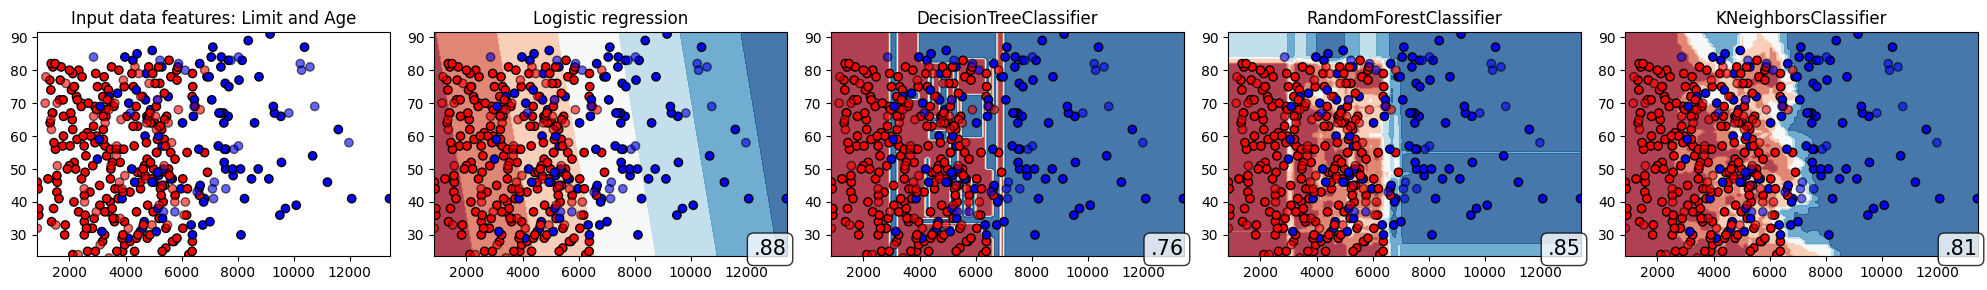

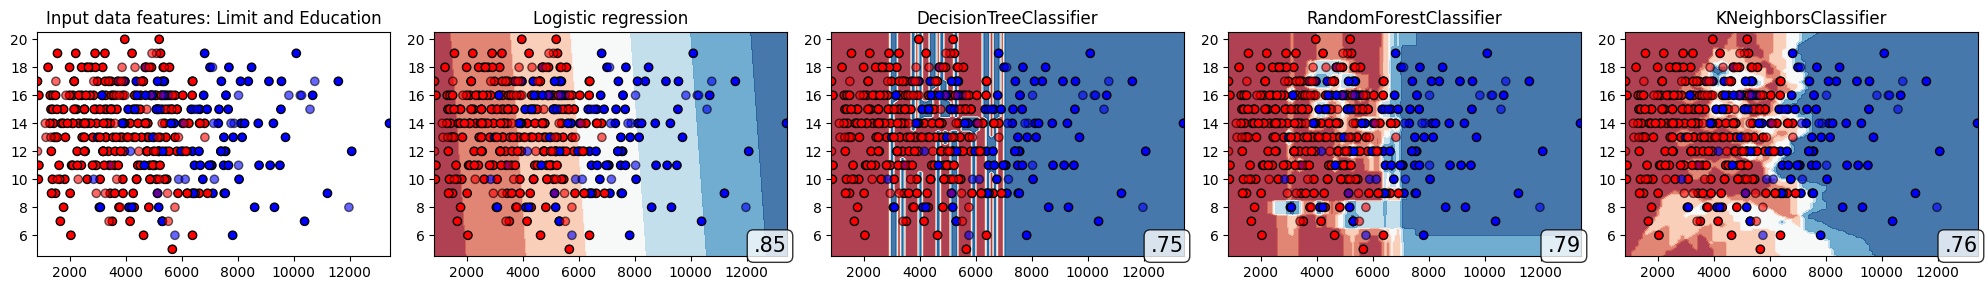

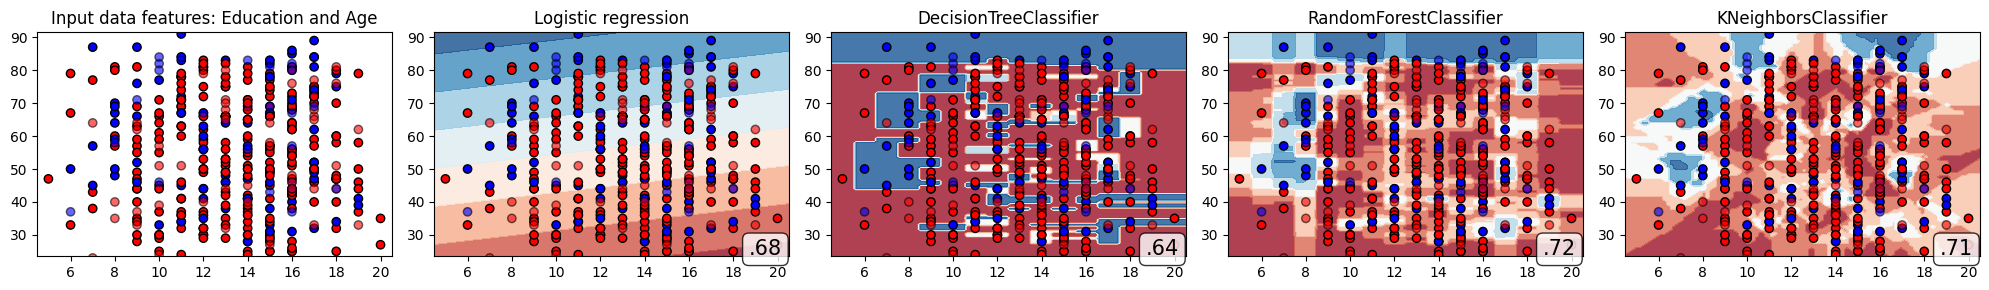

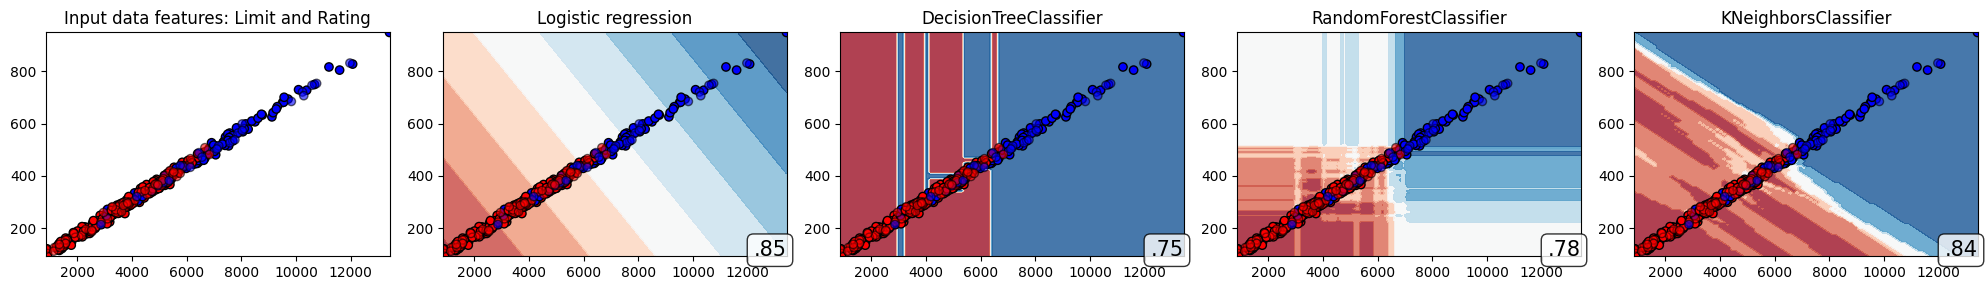

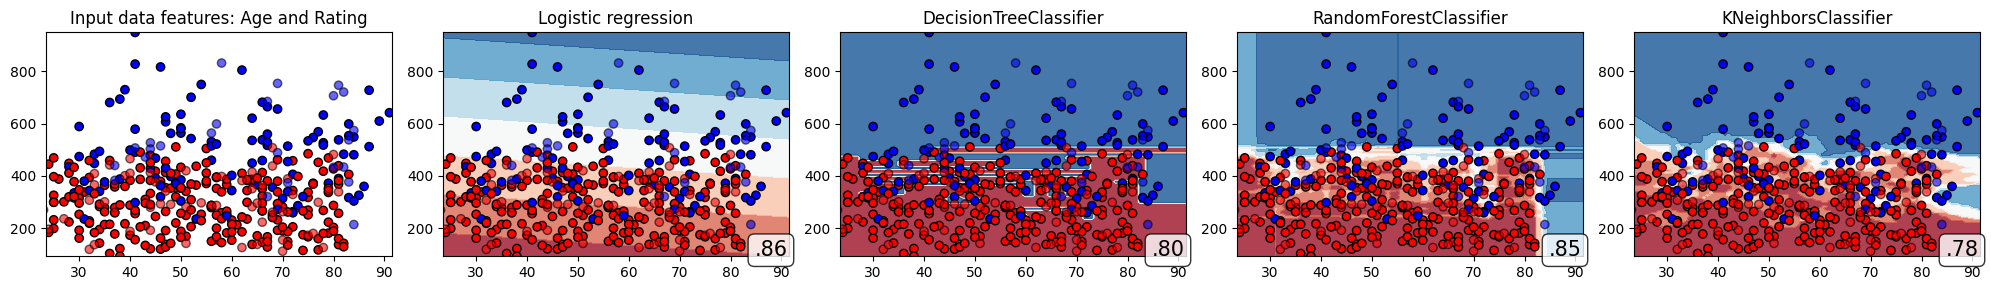

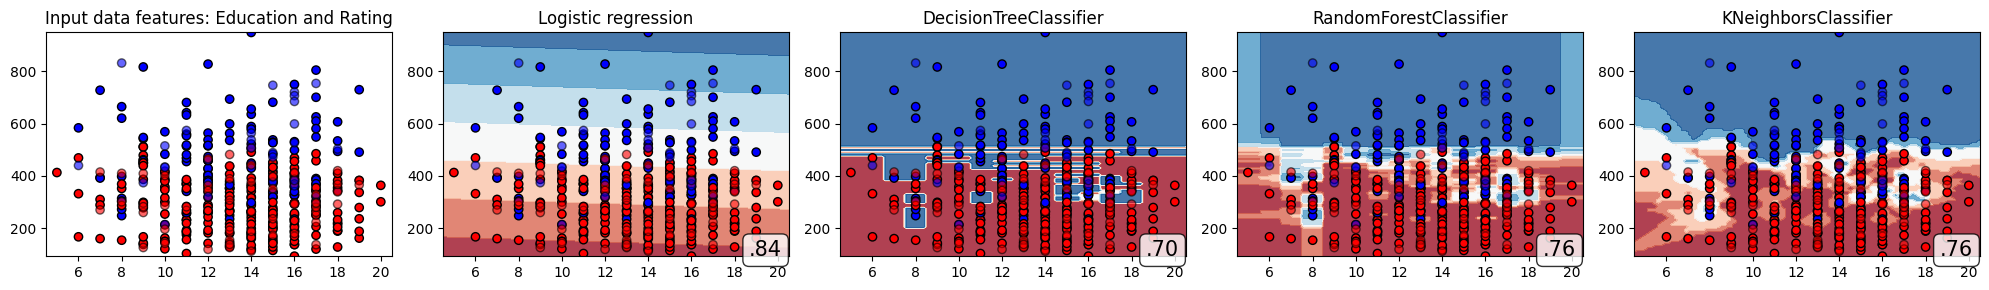

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

# Importy modeli
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


def draw_decision_boundaries(feature_cols):

    X_train_2d = x_train_income[feature_cols].values
    X_test_2d = x_test_income[feature_cols].values

    y_train_plot = y_train_income
    y_test_plot = y_test_income

    names = [
        "Logistic regression", "DecisionTreeClassifier", "RandomForestClassifier", "KNeighborsClassifier"
    ]

    classifiers = [
        LogisticRegression(max_iter=100),
        tree.DecisionTreeClassifier(),
        ensemble.RandomForestClassifier(n_estimators=100, max_depth=10),
        KNeighborsClassifier(n_neighbors=5),
    ]

    figure = plt.figure(figsize=(20, 3))
    i = 1

    x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5

    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])

    ax = plt.subplot(1, len(classifiers) + 1, i)
    ax.set_title(f"Input data features: {feature_cols[0]} and {feature_cols[1]}")

    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_plot, cmap=cm_bright, edgecolors="k")
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_plot, cmap=cm_bright, alpha=0.6, edgecolors="k")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    i += 1

    for name, clf in zip(names, classifiers):
        ax = plt.subplot(1, len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)

        clf.fit(X_train_2d, y_train_plot)

        score = clf.score(X_test_2d, y_test_plot)

        try:
            DecisionBoundaryDisplay.from_estimator(
                clf, X_train_2d, cmap=cm, alpha=0.8, ax=ax, eps=0.5
            )
        except Exception as e:
            print(f"Błąd rysowania dla {name}: {e}")

        ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_plot, cmap=cm_bright, edgecolors="k")
        ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_plot, cmap=cm_bright, edgecolors="k", alpha=0.6)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(name)
#
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
            bbox=dict(boxstyle="round", alpha=0.8, facecolor="white")
        )
        i += 1

    plt.tight_layout()
    plt.show()

draw_decision_boundaries(['Limit', 'Age'])    
draw_decision_boundaries(['Limit', 'Education'])    
draw_decision_boundaries(['Education', 'Age'])    
draw_decision_boundaries(['Limit', 'Rating'])    
draw_decision_boundaries(['Age', 'Rating'])    
draw_decision_boundaries(['Education', 'Rating'])    

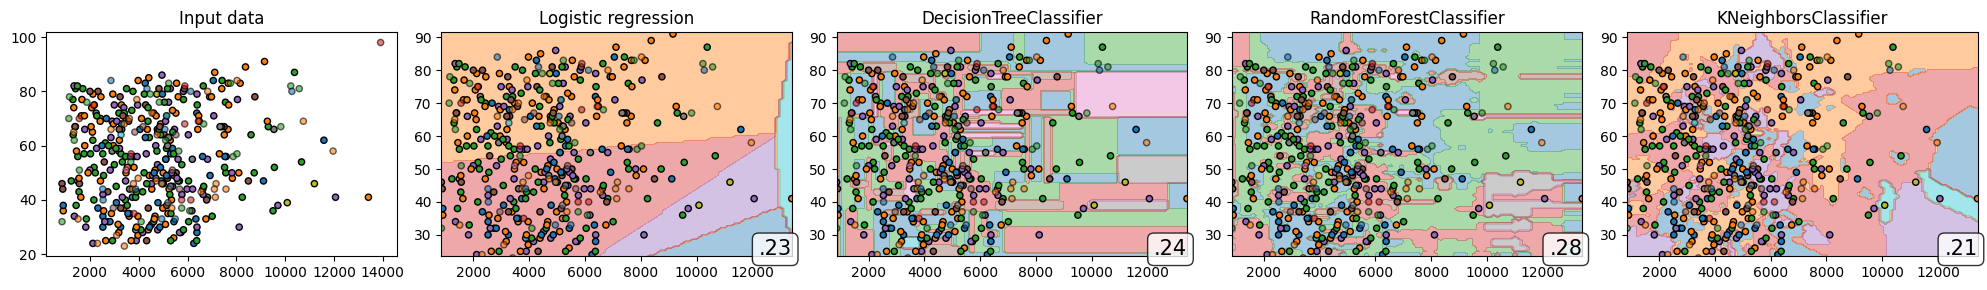

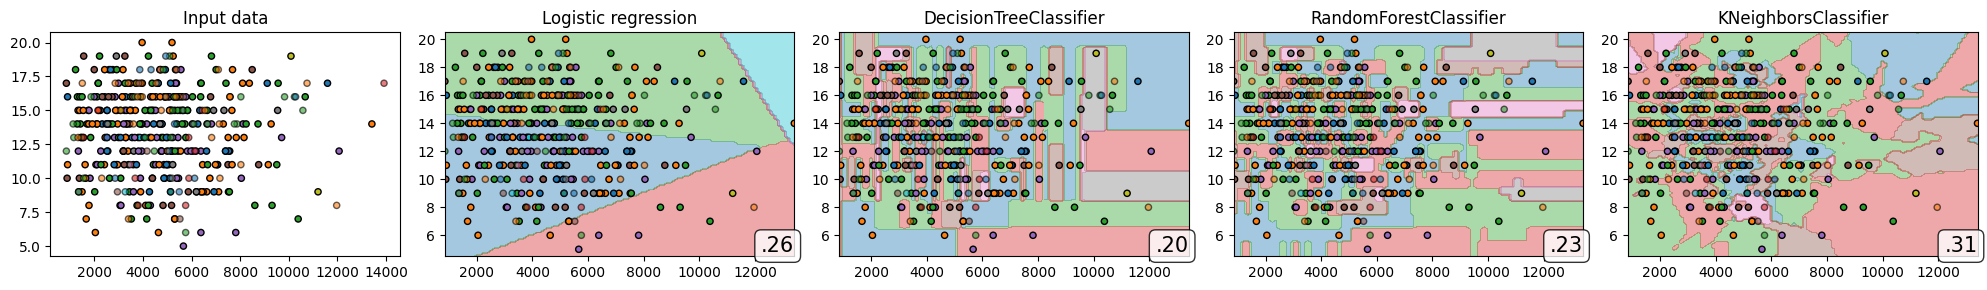

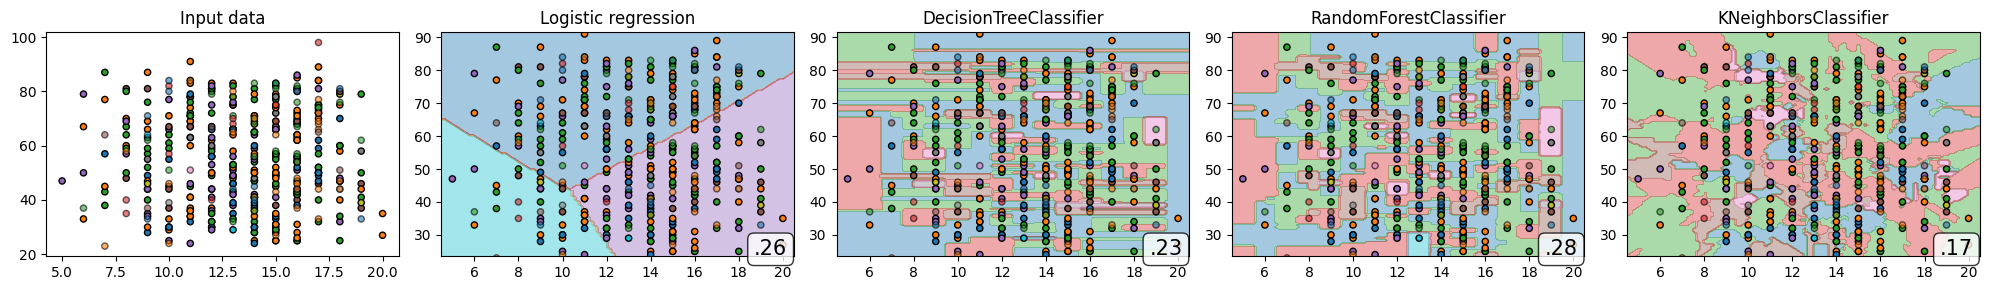

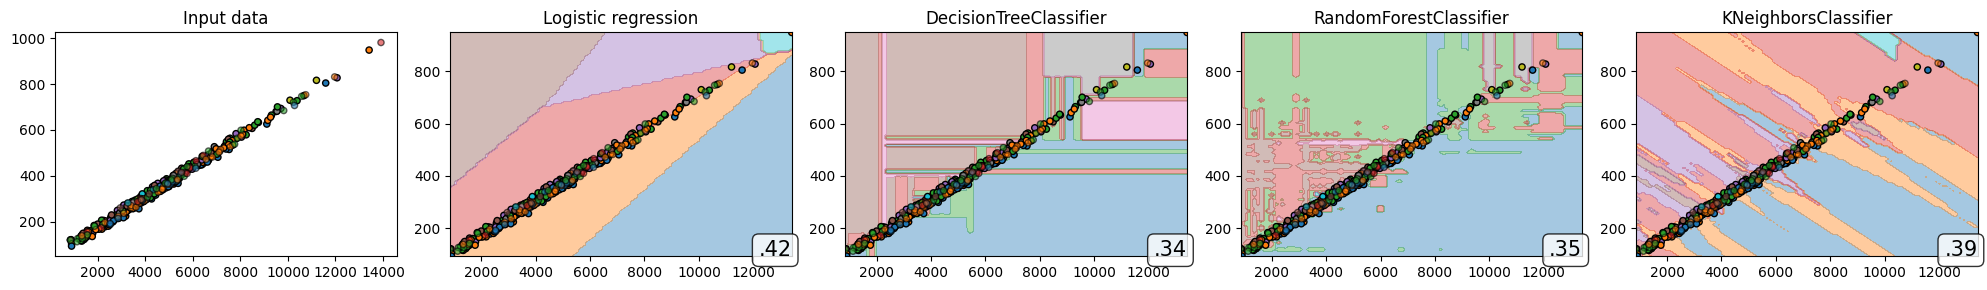

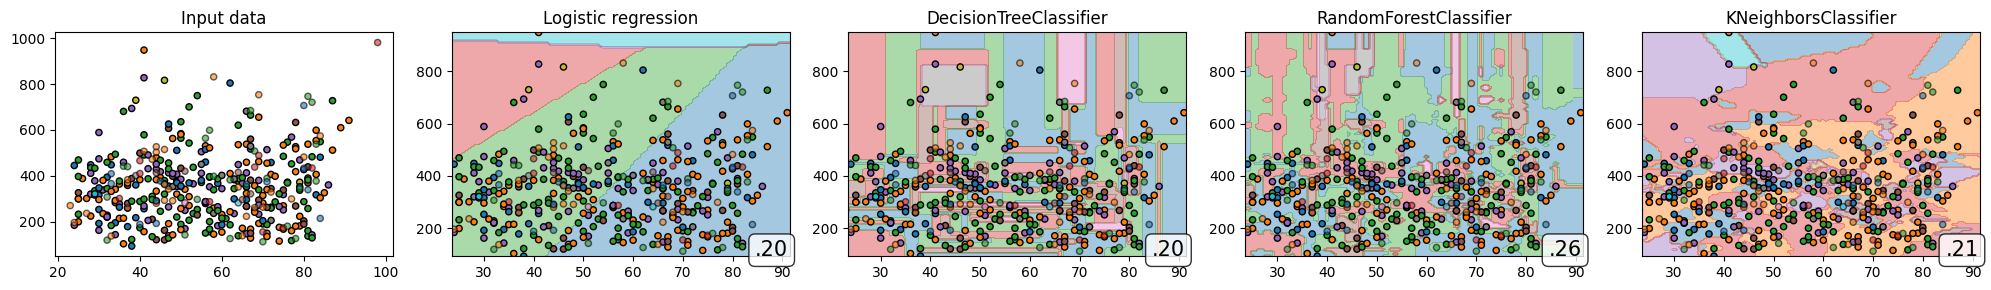

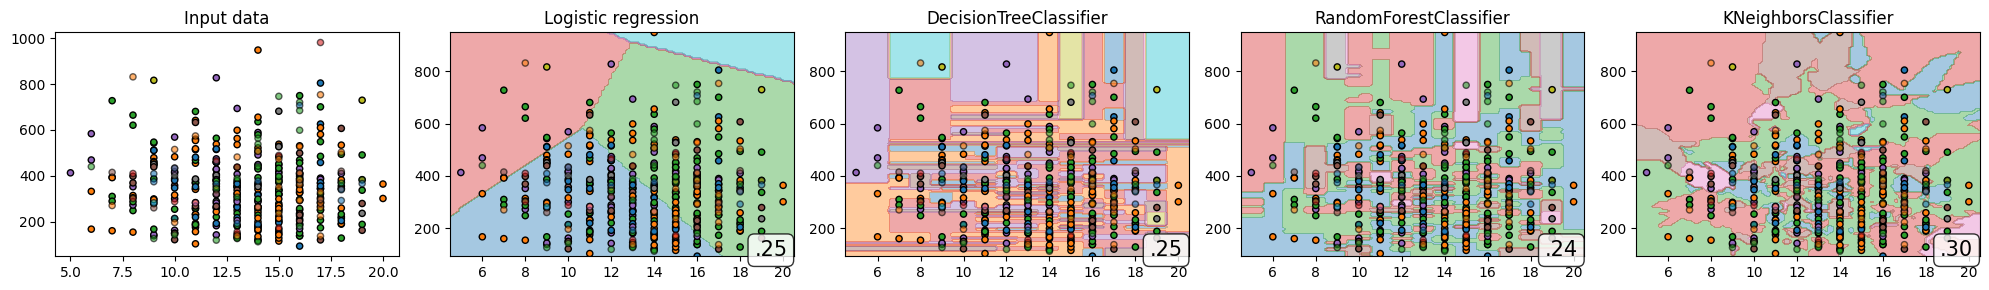

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


def draw_decision_boundaries(feature_cols):

    X_train_2d = x_train_cards[feature_cols].values
    X_test_2d = x_test_cards[feature_cols].values

    y_train_plot = y_train_cards
    y_test_plot = y_test_cards

    names = [
        "Logistic regression", "DecisionTreeClassifier", "RandomForestClassifier", "KNeighborsClassifier"
    ]

    classifiers = [
        LogisticRegression(max_iter=1000),
        tree.DecisionTreeClassifier(),
        ensemble.RandomForestClassifier(n_estimators=100, max_depth=100),
        KNeighborsClassifier(n_neighbors=5),
    ]

    cm = plt.cm.tab10 
    cm_bright = ListedColormap(plt.cm.tab10.colors) 

    figure = plt.figure(figsize=(20, 3))
    i = 1

    x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5

    ax = plt.subplot(1, len(classifiers) + 1, i)
    ax.set_title("Input data")

    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_plot, cmap=cm_bright, edgecolors="k", s=20)
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_plot, cmap=cm_bright, alpha=0.6, edgecolors="k", s=20)

    i += 1
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(1, len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)

        clf.fit(X_train_2d, y_train_plot)

        score = clf.score(X_test_2d, y_test_plot)

        try:
            DecisionBoundaryDisplay.from_estimator(
                clf,
                X_train_2d,
                cmap=cm,
                response_method="predict",
                alpha=0.4,
                ax=ax,
                eps=0.5
            )
        except Exception as e:
            print(f"Błąd rysowania dla {name}: {e}")

        ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_plot, cmap=cm_bright, edgecolors="k", s=20)
        ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_plot, cmap=cm_bright, edgecolors="k", alpha=0.6, s=20)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(name)

        ax.text(
            x_max - 0.3, y_min + 0.3, ("%.2f" % score).lstrip("0"),
            size=15, horizontalalignment="right",
            bbox=dict(boxstyle="round", alpha=0.8, facecolor="white")
        )
        i += 1

    plt.tight_layout()
    plt.show()

draw_decision_boundaries(['Limit', 'Age'])    
draw_decision_boundaries(['Limit', 'Education'])    
draw_decision_boundaries(['Education', 'Age'])    
draw_decision_boundaries(['Limit', 'Rating'])    
draw_decision_boundaries(['Age', 'Rating'])    
draw_decision_boundaries(['Education', 'Rating'])   